# Importing Modules

In [1]:
import pandas as pd
import numpy as np
import re
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import joblib    

In [2]:
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\laesc\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\laesc\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\laesc\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\laesc\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

# Data Preprocessing

In [3]:
# Using the phishing email dataset from Kaggle:
# https://www.kaggle.com/datasets/naserabdullahalam/phishing-email-dataset
df = pd.read_csv('phishing_email.csv') 

In [4]:
# Step 1: Normalization
def normalize(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()                                   # Lowercase all text
    text = re.sub(r'<[^>]+>', ' ', text)                  # Remove HTML tags
    text = re.sub(r'http\S+|www\.\S+', 'urltoken', text)  # Replace URLs with token
    text = re.sub(r'\S+@\S+', 'emailtoken', text)         # Replace email addresses with token
    text = re.sub(r'[^a-z\s]', ' ', text)                 # Remove punctuation & special chars
    text = re.sub(r'\s+', ' ', text).strip()              # Remove extra whitespace
    return text

df['normalized'] = df['text_combined'].apply(normalize)
df[['text_combined', 'normalized']].head()

,text_combined,normalized
0,hpl nom may 25 2001 see attached file hplno 52...,hpl nom may see attached file hplno xls hplno xls
1,nom actual vols 24 th forwarded sabrae zajac h...,nom actual vols th forwarded sabrae zajac hou ...
2,enron actuals march 30 april 1 201 estimated a...,enron actuals march april estimated actuals ma...
3,hpl nom may 30 2001 see attached file hplno 53...,hpl nom may see attached file hplno xls hplno xls
4,hpl nom june 1 2001 see attached file hplno 60...,hpl nom june see attached file hplno xls hplno...


In [5]:
# Step 2: Tokenization
def tokenize(text):
    return word_tokenize(text)  # Splits string into a list of individual word tokens

df['tokenized'] = df['normalized'].apply(tokenize)
df[['normalized', 'tokenized']].head()

,normalized,tokenized
0,hpl nom may see attached file hplno xls hplno xls,"[hpl, nom, may, see, attached, file, hplno, xl..."
1,nom actual vols th forwarded sabrae zajac hou ...,"[nom, actual, vols, th, forwarded, sabrae, zaj..."
2,enron actuals march april estimated actuals ma...,"[enron, actuals, march, april, estimated, actu..."
3,hpl nom may see attached file hplno xls hplno xls,"[hpl, nom, may, see, attached, file, hplno, xl..."
4,hpl nom june see attached file hplno xls hplno...,"[hpl, nom, june, see, attached, file, hplno, x..."


In [6]:
# Step 3: Stop Word Removal
stop_words = set(stopwords.words('english'))

def remove_stopwords(tokens):
    return [t for t in tokens if t not in stop_words]

df['no_stopwords'] = df['tokenized'].apply(remove_stopwords)
df[['tokenized', 'no_stopwords']].head()

,tokenized,no_stopwords
0,"[hpl, nom, may, see, attached, file, hplno, xl...","[hpl, nom, may, see, attached, file, hplno, xl..."
1,"[nom, actual, vols, th, forwarded, sabrae, zaj...","[nom, actual, vols, th, forwarded, sabrae, zaj..."
2,"[enron, actuals, march, april, estimated, actu...","[enron, actuals, march, april, estimated, actu..."
3,"[hpl, nom, may, see, attached, file, hplno, xl...","[hpl, nom, may, see, attached, file, hplno, xl..."
4,"[hpl, nom, june, see, attached, file, hplno, x...","[hpl, nom, june, see, attached, file, hplno, x..."


In [7]:
# Step 4: Stemming/Lemmatization
lemmatizer = WordNetLemmatizer()

def lemmatize(tokens):
    return [lemmatizer.lemmatize(t) for t in tokens]

df['lemmatized'] = df['no_stopwords'].apply(lemmatize)
df[['no_stopwords', 'lemmatized']].head()

,no_stopwords,lemmatized
0,"[hpl, nom, may, see, attached, file, hplno, xl...","[hpl, nom, may, see, attached, file, hplno, xl..."
1,"[nom, actual, vols, th, forwarded, sabrae, zaj...","[nom, actual, vols, th, forwarded, sabrae, zaj..."
2,"[enron, actuals, march, april, estimated, actu...","[enron, actuals, march, april, estimated, actu..."
3,"[hpl, nom, may, see, attached, file, hplno, xl...","[hpl, nom, may, see, attached, file, hplno, xl..."
4,"[hpl, nom, june, see, attached, file, hplno, x...","[hpl, nom, june, see, attached, file, hplno, x..."


In [8]:
# Step 5: Rejoin the processed text into one string
df['clean_text'] = df['lemmatized'].apply(lambda tokens: ' '.join(tokens))
df[['lemmatized', 'clean_text']].head()

,lemmatized,clean_text
0,"[hpl, nom, may, see, attached, file, hplno, xl...",hpl nom may see attached file hplno xl hplno xl
1,"[nom, actual, vols, th, forwarded, sabrae, zaj...",nom actual vols th forwarded sabrae zajac hou ...
2,"[enron, actuals, march, april, estimated, actu...",enron actuals march april estimated actuals ma...
3,"[hpl, nom, may, see, attached, file, hplno, xl...",hpl nom may see attached file hplno xl hplno xl
4,"[hpl, nom, june, see, attached, file, hplno, x...",hpl nom june see attached file hplno xl hplno xl


In [9]:
# Step 6: Vectorization
vectorizer = TfidfVectorizer(max_features=3000)  # Use the top 3000 most meaningful words

X = vectorizer.fit_transform(df['clean_text'])  # Input the feature
y = df['label']                                 # Prediction target (0 = legitimate, 1 = phishing)

print(f'Matrix shape: {X.shape}')  

Matrix shape: (82486, 3000)


In [10]:
# Step 7: Perform train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Training set size: {X_train.shape[0]} emails')
print(f'Test set size:     {X_test.shape[0]} emails')

Training set size: 65988 emails
Test set size:     16498 emails


# Building the Model

In [11]:
# Compare several models to find the best suited
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Naive Bayes':         MultinomialNB(),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM':                 LinearSVC(max_iter=1000),
    'XGBoost':             XGBClassifier(n_estimators=100, random_state=42)
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    results.append({
        'Model':    name,
        'Accuracy': f'{accuracy_score(y_test, y_pred):.2%}',
        'F1 Score': f'{f1_score(y_test, y_pred):.2%}'
    })

results_df = pd.DataFrame(results)
results_df.sort_values('F1 Score', ascending=False)

,Model,Accuracy,F1 Score
2,Random Forest,98.43%,98.49%
3,SVM,98.01%,98.09%
4,XGBoost,97.82%,97.92%
0,Logistic Regression,97.73%,97.82%
1,Naive Bayes,95.54%,95.65%


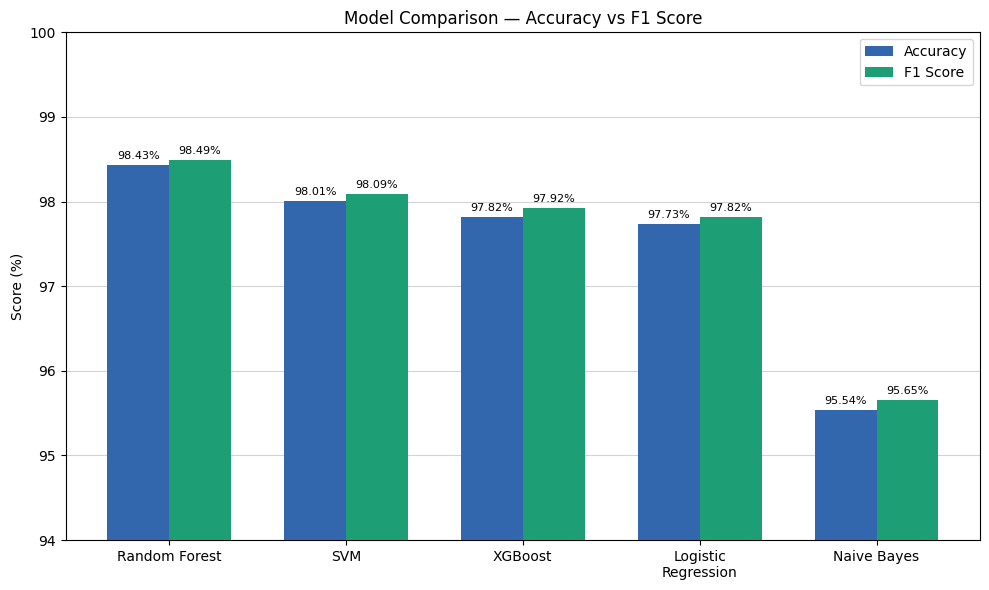

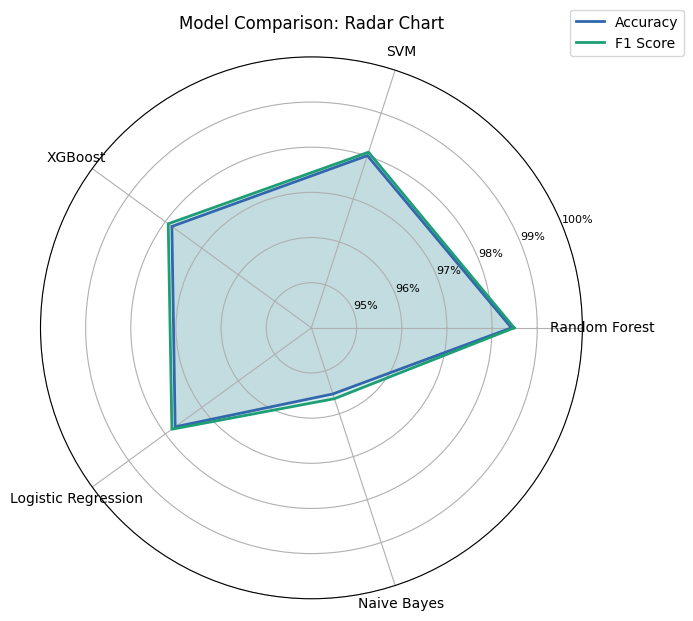

In [15]:
# Visualizations of results

# Barchart
models = ['Random Forest', 'SVM', 'XGBoost', 'Logistic\nRegression', 'Naive Bayes']
accuracy = [98.43, 98.01, 97.82, 97.73, 95.54]
f1 = [98.49, 98.09, 97.92, 97.82, 95.65]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, accuracy, width, label='Accuracy', color='#3266ad', zorder=3)
bars2 = ax.bar(x + width/2, f1, width, label='F1 Score', color='#1D9E75', zorder=3)

ax.set_ylim(94, 100)
ax.set_ylabel('Score (%)')
ax.set_title('Model Comparison — Accuracy vs F1 Score')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()
ax.yaxis.grid(True, color='lightgray', zorder=0)
ax.set_axisbelow(True)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{bar.get_height():.2f}%', ha='center', va='bottom', fontsize=8)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{bar.get_height():.2f}%', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Radar chart
models = ['Random Forest', 'SVM', 'XGBoost', 'Logistic\nRegression', 'Naive Bayes']
accuracy = [98.43, 98.01, 97.82, 97.73, 95.54]
f1 = [98.49, 98.09, 97.92, 97.82, 95.65]

angles = np.linspace(0, 2 * np.pi, len(models), endpoint=False).tolist()
accuracy_plot = accuracy + [accuracy[0]]
f1_plot = f1 + [f1[0]]
angles += angles[:1]
labels = [m.replace('\n', ' ') for m in models]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
ax.plot(angles, accuracy_plot, color='#3266ad', linewidth=2, label='Accuracy')
ax.fill(angles, accuracy_plot, color='#3266ad', alpha=0.15)
ax.plot(angles, f1_plot, color='#1D9E75', linewidth=2, label='F1 Score')
ax.fill(angles, f1_plot, color='#1D9E75', alpha=0.15)

ax.set_thetagrids(np.degrees(angles[:-1]), labels, fontsize=10)
ax.set_ylim(94, 100)
ax.set_yticks([95, 96, 97, 98, 99, 100])
ax.set_yticklabels(['95%', '96%', '97%', '98%', '99%', '100%'], fontsize=8)
ax.set_title('Model Comparison: Radar Chart', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.2, 1.1))

plt.tight_layout()
plt.savefig('model_radar.png', dpi=150, bbox_inches='tight')
plt.show()

n_estimators= 10 | Train: 99.89% | Test: 97.25%
n_estimators= 20 | Train: 99.98% | Test: 97.88%
n_estimators= 30 | Train: 99.99% | Test: 98.02%
n_estimators= 40 | Train: 99.99% | Test: 98.24%
n_estimators= 50 | Train: 99.99% | Test: 98.30%
n_estimators= 60 | Train: 99.99% | Test: 98.42%
n_estimators= 70 | Train: 99.99% | Test: 98.41%
n_estimators= 80 | Train: 99.99% | Test: 98.42%
n_estimators= 90 | Train: 99.99% | Test: 98.43%
n_estimators=100 | Train: 99.99% | Test: 98.43%


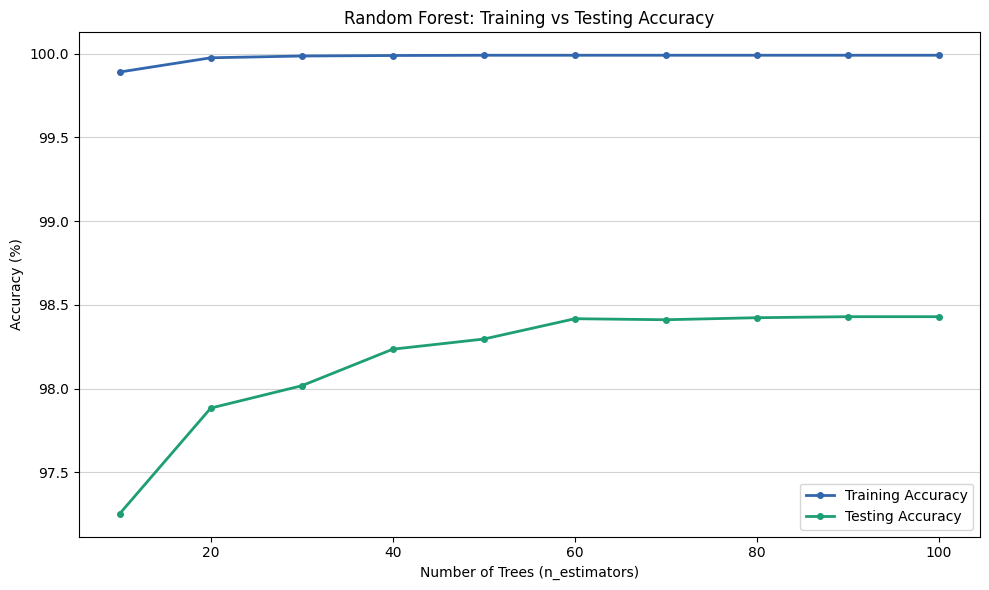

Confusion Matrix:
[[7818  117]
 [ 142 8421]]

Classification Report:
              precision    recall  f1-score   support

  Legitimate       0.98      0.99      0.98      7935
    Phishing       0.99      0.98      0.98      8563

    accuracy                           0.98     16498
   macro avg       0.98      0.98      0.98     16498
weighted avg       0.98      0.98      0.98     16498



In [13]:
# As random forest performed best, create standalone model to save and analyze further
train_accuracies = []
test_accuracies = []
estimator_range = range(10, 101, 10)

for n in estimator_range:
    rf = RandomForestClassifier(n_estimators=n, random_state=42)
    rf.fit(X_train, y_train)
    train_accuracies.append(accuracy_score(y_train, rf.predict(X_train)) * 100)
    test_accuracies.append(accuracy_score(y_test, rf.predict(X_test)) * 100)
    print(f'n_estimators={n:>3} | Train: {train_accuracies[-1]:.2f}% | Test: {test_accuracies[-1]:.2f}%')

y_pred = rf.predict(X_test)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(estimator_range, train_accuracies, color='#3266ad', linewidth=2, marker='o',
        markersize=4, label='Training Accuracy')
ax.plot(estimator_range, test_accuracies, color='#1D9E75', linewidth=2, marker='o',
        markersize=4, label='Testing Accuracy')
ax.set_xlabel('Number of Trees (n_estimators)')
ax.set_ylabel('Accuracy (%)')
ax.set_title('Random Forest: Training vs Testing Accuracy')
ax.legend()
ax.yaxis.grid(True, color='lightgray')
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

print('Confusion Matrix:')
print(confusion_matrix(y_test, y_pred))
print()
print('Classification Report:')
print(classification_report(y_test, y_pred, target_names=['Legitimate', 'Phishing']))

# Analysis of Model Performance

## Evaluation Metrics

### Accuracy
The percentage of emails the model classified correctly overall. Simple, but can be misleading if the dataset is imbalanced.

### Classification Report
Provides three more detailed metrics per class:

| Metric | What it means |
|---|---|
| **Precision** | Of all emails predicted as phishing, how many actually were? |
| **Recall** | Of all actual phishing emails, how many did the model catch? |
| **F1 Score** | The balance between precision and recall, the most important metric |

### Confusion Matrix
A 2x2 grid showing exactly where the model got confused:

|  | Predicted Legitimate | Predicted Phishing |
|---|---|---|
| **Actual Legitimate** | True Negative | False Positive |
| **Actual Phishing** | False Negative | True Positive |

> **False Negatives** are the most dangerous for this use case, these are real phishing emails the model missed and let through.